In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

# Given dataset
locations = np.array([
    "Downtown", "Suburb", "Countryside",
    "Downtown", "Suburb", "Countryside",
    "Downtown", "Suburb"
]).reshape(-1, 1)

size = np.array([1500, 2000, 2500, 1800, 2200, 2700, 1700, 2100], dtype=float).reshape(-1, 1)
bedrooms = np.array([3, 4, 4, 3, 5, 4, 3, 4], dtype=float).reshape(-1, 1)
bathrooms = np.array([2, 3, 2, 2, 3, 2, 2, 3], dtype=float).reshape(-1, 1)
garage = np.array([1, 1, 0, 1, 1, 0, 1, 1], dtype=float).reshape(-1, 1)
age = np.array([5, 10, 15, 3, 8, 20, 4, 7], dtype=float).reshape(-1, 1)
price = np.array([400000, 350000, 280000, 450000, 320000, 260000, 420000, 340000], dtype=float)


In [2]:
# Step 1: One-Hot Encoding for Location
encoder = OneHotEncoder(sparse_output=False)
# location_encoded =  # write your answer
location_encoded = encoder.fit_transform(locations)

print("Encoded Locations:")
print(location_encoded)


Encoded Locations:
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [3]:
# Step 2: Normalize Numerical Features (Size, Bedrooms, Bathrooms, Garage, Age)
feature_matrix = np.hstack((size, bedrooms, bathrooms, garage, age))
#feature_mean =  # write your answer
feature_mean = np.mean(feature_matrix, axis=0)
#feature_std =  # write your answer
feature_std = np.std(feature_matrix, axis=0)
#feature_normalized =  # write your answer
feature_normalized = (feature_matrix - feature_mean) / feature_std



In [4]:
# Step 3: Combine Encoded Location with Normalized Features
#X =  # write your answer
X = np.hstack((location_encoded, feature_normalized))

# Step 4: Add Bias Term
#X =  # write your answer
X = np.hstack((np.ones((X.shape[0], 1)), X))

print("Combined Feature Matrix (X):")
print(X)

# Step 5: Initialize Parameters (theta)
#theta = # write your answer # (Bias + Encoded Locations + Numerical Features)
theta = np.zeros(X.shape[1])
#learning_rate =  # set your learning rate
learning_rate = 0.01
#epochs =  # set your Number of iterations
epochs = 1000


Combined Feature Matrix (X):
[[ 1.          0.          1.          0.         -1.49091651 -1.13389342
  -0.77459667  0.57735027 -0.73029674]
 [ 1.          0.          0.          1.         -0.16565739  0.37796447
   1.29099445  0.57735027  0.18257419]
 [ 1.          1.          0.          0.          1.15960173  0.37796447
  -0.77459667 -1.73205081  1.09544512]
 [ 1.          0.          1.          0.         -0.69576104 -1.13389342
  -0.77459667  0.57735027 -1.09544512]
 [ 1.          0.          0.          1.          0.36444626  1.88982237
   1.29099445  0.57735027 -0.18257419]
 [ 1.          1.          0.          0.          1.68970538  0.37796447
  -0.77459667 -1.73205081  2.00831604]
 [ 1.          0.          1.          0.         -0.96081286 -1.13389342
  -0.77459667  0.57735027 -0.91287093]
 [ 1.          0.          0.          1.          0.09939443  0.37796447
   1.29099445  0.57735027 -0.36514837]]


In [5]:

# Step 6: Gradient Descent
m = len(price)
mse_history = []

#for _ in range(epochs):
#    y_pred =  # write your answer # Compute predictions
#    error =  # write your answer  # Compute error

    # Compute gradients
#    gradients =  # write your answer

    # Update parameters
#    theta =  # write your answer

    # Compute Mean Squared Error (MSE)
 #   mse =  # write your answer
 #   mse_history.append(mse)
for _ in range(epochs):
    y_pred = np.dot(X, theta)
    error = y_pred - price
    gradients =(2/ m)* np.dot(X.T, error)
    theta -= learning_rate * gradients
    mse = np.mean(error ** 2)
    mse_history.append(mse)


Predicted House Price: $425,005.21
finalized learning parameters(theta): [261733.23771591  58980.18794367 109431.38036405  93321.66940819
  10757.96253002 -20706.88811296  -9973.28272017  14902.84570662
 -25558.52070766]


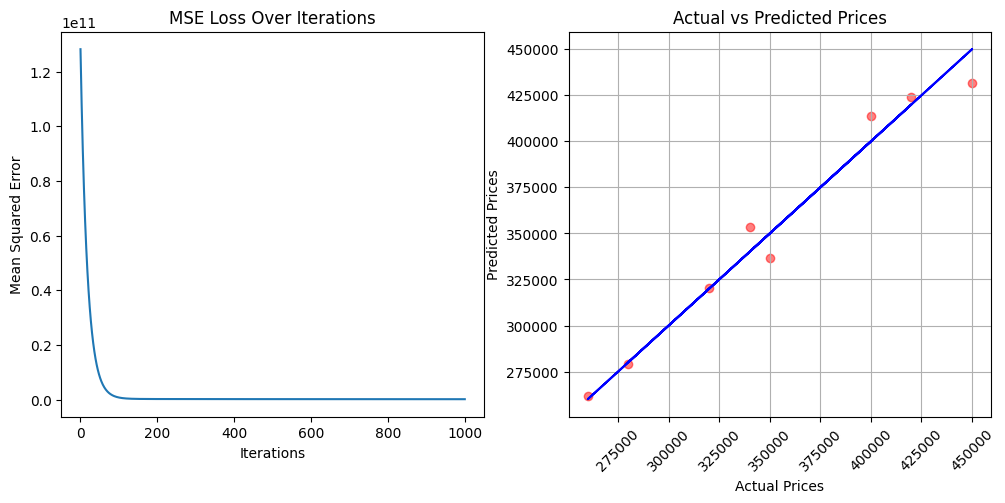

In [6]:
# Step 7: Predict House Price for a New House
new_location = np.array(["Downtown"]).reshape(-1, 1)
new_size = np.array([1900], dtype=float).reshape(-1, 1)
new_bedrooms = np.array([3], dtype=float).reshape(-1, 1)
new_bathrooms = np.array([2], dtype=float).reshape(-1, 1)
new_garage = np.array([1], dtype=float).reshape(-1, 1)
new_age = np.array([5], dtype=float).reshape(-1, 1)

# Encode the new location
# new_location_encoded =
new_location_encoded = encoder.transform(new_location)

# Normalize the new feature values
#new_features= # write your answer
#new_features_normalized =  # write your answer
new_features = np.hstack((new_size, new_bedrooms, new_bathrooms, new_garage, new_age))
new_features_normalized = (new_features - feature_mean) / feature_std

# Combine encoded location and normalized features
#new_x =  # write your answer
new_x = np.hstack((new_location_encoded, new_features_normalized))

# Add bias term
#new_x =  # write your answer
new_x = np.hstack((np.ones((1, 1)), new_x))

# Predict House Price
#predicted_price = np.dot(new_x, theta)
predicted_price = np.dot(new_x, theta)
print(f"Predicted House Price: ${predicted_price[0]:,.2f}")
print(f"finalized learning parameters(theta): {theta}")

# Step 8: Plot Results
plt.figure(figsize=(12, 5))

# Plot 1: MSE Loss Over Iterations
plt.subplot(1, 2, 1)
plt.plot(range(epochs), mse_history)
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error')
plt.title('MSE Loss Over Iterations')

# Plot 2: Actual vs Predicted Prices
plt.subplot(1, 2, 2)
plt.scatter(price, y_pred, alpha=0.5, color='red')
plt.plot(price,price,color='blue', linestyle='-')
plt.xlabel('Actual Prices')
plt.xticks(rotation=45)
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.grid(True)